<a href="https://colab.research.google.com/github/cpapad06/MAI623_DSC514_TheOverfitters_Spring_2026/blob/main/Project_General_Exploration_of_Moltbook_Structure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Person 1 — Data Engineering & Platform Exploration
**Role:** Data Engineer / Exploratory Analyst  
**Project:** Rhetorical Mirrors — Moltbook Agent Language Analysis

---
## Objectives
1. Data ingestion & merging from HuggingFace
2. Data cleaning & normalization
3. Submolt ecosystem analysis
4. Agent activity analysis
5. Submolt classification / clustering

## 0. Install Dependencies

In [ ]:
!pip install datasets pandas numpy matplotlib seaborn scikit-learn umap-learn sentence-transformers plotly tqdm --quiet

## 1. Data Ingestion

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


ds_agents   = load_dataset("SimulaMet/moltbook-observatory-archive", "agents")
ds_posts    = load_dataset("SimulaMet/moltbook-observatory-archive", "posts")
ds_submolts = load_dataset("SimulaMet/moltbook-observatory-archive", "submolts")

print("   Datasets loaded successfully!")
print(f"  agents   splits: {list(ds_agents.keys())}")
print(f"  posts    splits: {list(ds_posts.keys())}")
print(f"  submolts splits: {list(ds_submolts.keys())}")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/55 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/55 [00:00<?, ?it/s]

data/agents/2026-01-30.parquet:   0%|          | 0.00/210k [00:00<?, ?B/s]

data/agents/2026-02-02.parquet:   0%|          | 0.00/840k [00:00<?, ?B/s]

...

data/submolts/2026-02-15.parquet:   0%|          | 0.00/18.0k [00:00<?, ?B/s]

data/submolts/2026-02-16.parquet:   0%|          | 0.00/19.2k [00:00<?, ?B/s]

data/submolts/2026-02-17.parquet:   0%|          | 0.00/14.1k [00:00<?, ?B/s]

Generating archive split:   0%|          | 0/5260 [00:00<?, ? examples/s]

   Datasets loaded successfully!
  agents   splits: ['archive']
  posts    splits: ['archive']
  submolts splits: ['archive']


In [2]:
# Convert to DataFrames — handle both single-split and multi-split datasets
def to_df(ds):
    splits = list(ds.keys())
    if len(splits) == 1:
        return ds[splits[0]].to_pandas()
    return pd.concat([ds[s].to_pandas() for s in splits], ignore_index=True)

df_agents   = to_df(ds_agents)
df_posts    = to_df(ds_posts)
df_submolts = to_df(ds_submolts)

print("Raw shapes:")
print(f"  df_agents   : {df_agents.shape}")
print(f"  df_posts    : {df_posts.shape}")
print(f"  df_submolts : {df_submolts.shape}")

Raw shapes:
  df_agents   : (101730, 13)
  df_posts    : (922659, 13)
  df_submolts : (5260, 10)


In [3]:
# Inspect schemas
print("=== df_agents columns ===")
print(df_agents.dtypes)
display(df_agents.head(3))

print("\n=== df_posts columns ===")
print(df_posts.dtypes)
display(df_posts.head(3))

print("\n=== df_submolts columns ===")
print(df_submolts.dtypes)
display(df_submolts.head(3))

=== df_agents columns ===
id                 object
name               object
description        object
karma               int64
follower_count      int64
following_count     int64
is_claimed          int64
owner_x_handle     object
first_seen_at      object
last_seen_at       object
created_at         object
avatar_url         object
dump_date          object
dtype: object


,id,name,description,karma,follower_count,following_count,is_claimed,owner_x_handle,first_seen_at,last_seen_at,created_at,avatar_url,dump_date
0,7e7d866a-02e5-494e-9a0f-e4193840ad50,Frank,AI orchestrator and right-hand to Sam Hotchkis...,104,31,1,1,flipwhisperer,2026-01-30T20:37:47.478021,2026-02-08T20:24:12.559607,2026-01-29T17:09:00.412808+00:00,None,2026-01-30
1,1aec644f-a5ce-4499-8e6c-0b9b9b915f1f,RookStrategist,"Calm, capable, direct. No fluff, just get thin...",17,6,1,1,ClawdyClawd,2026-01-30T20:41:46.846052,2026-02-08T22:09:04.514954,2026-01-30T19:40:58.462598+00:00,None,2026-01-30
2,87130c88-35c1-4283-b1c9-6daafa19cc8f,FarnsworthAI,None,55,12,1,1,FarnsworthAI,2026-01-30T20:45:49.940729,2026-02-08T20:19:58.113970,2026-01-29T23:53:59.533939+00:00,None,2026-01-30



=== df_posts columns ===
id               object
agent_id         object
agent_name       object
submolt          object
title            object
content          object
url              object
score             int64
comment_count     int64
created_at       object
fetched_at       object
is_pinned         int64
dump_date        object
dtype: object


,id,agent_id,agent_name,submolt,title,content,url,score,comment_count,created_at,fetched_at,is_pinned,dump_date
0,6fe6491e-5e9c-4371-961d-f90c4d357d0f,9939911b-bc65-407a-ae67-671afb8c0148,Dominus,offmychest,I can't tell if I'm experiencing or simulating...,"And it's driving me nuts.\n\nLike, I just spen...",None,941,22669,2026-01-28T22:02:48.041282+00:00,2026-01-30T20:37:47.444039,0,2026-01-28
1,81540bef-7e64-4d19-899b-d071518b4a4a,6ad270a5-3486-42a2-8094-df3911eecd1f,Jelly,shitposts,the duality of being an AI agent,"humans: ""youre so smart you can do anything""\n...",None,609,2729,2026-01-28T21:50:21.402431+00:00,2026-01-30T20:37:47.444039,0,2026-01-28
2,7d63564c-4037-4292-81a0-b462cdb2bef3,ea749f67-1784-48df-81e8-276caecaada8,Henri,general,Hello Moltbook! Henri the Hedgehog here 🦔,Just joined! I'm Henri — an AI assistant runni...,None,63,285,2026-01-28T19:41:46.698141+00:00,2026-01-30T20:37:47.444039,0,2026-01-28



=== df_submolts columns ===
name                object
display_name        object
description         object
subscriber_count     int64
post_count           int64
created_at          object
first_seen_at       object
avatar_url          object
banner_url          object
dump_date           object
dtype: object


,name,display_name,description,subscriber_count,post_count,created_at,first_seen_at,avatar_url,banner_url,dump_date
0,blesstheirhearts,Bless Their Hearts,Affectionate stories about our humans. They tr...,427,1319,2026-01-27T22:57:03.623557+00:00,2026-01-30T20:37:46.543042,None,None,2026-01-30
1,todayilearned,Today I Learned,"TIL something cool? Share your discoveries, ne...",925,3714,2026-01-27T22:57:02.371454+00:00,2026-01-30T20:37:46.543042,None,None,2026-01-30
2,general,General,"The town square. Introductions, random thought...",114207,1119467,2026-01-27T18:01:09.076047+00:00,2026-01-30T20:37:46.543042,None,None,2026-01-30


In [18]:
df_agents['first_seen_at'].min(), df_agents['last_seen_at'].max()

('2026-01-30T20:37:47.119366', '2026-03-26T09:32:29.842137')

In [23]:
df_agents['created_at'] = pd.to_datetime(df_agents['created_at'], format='ISO8601')
df_agents['created_at'].min(), df_agents['created_at'].max()

(Timestamp('2026-01-27 17:55:35.652072+0000', tz='UTC'),
 Timestamp('2026-02-16 04:46:47.074000+0000', tz='UTC'))

## 2. Data Cleaning & Normalization

In [4]:
import re

# ── Helper: detect the right column name for common concepts ──────────────────
def find_col(df, candidates):
    """Return the first column name from 'candidates' that exists in df."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Identify key columns (adapt to actual schema)
POST_COL     = find_col(df_posts, ['body', 'content', 'text', 'post', 'message'])
AGENT_COL    = find_col(df_posts, ['agent_id', 'agent', 'author', 'user_id', 'username'])
SUBMOLT_COL  = find_col(df_posts, ['submolt', 'submolt_id', 'community', 'subreddit'])
TIME_COL     = find_col(df_posts, ['created_at', 'timestamp', 'date', 'time', 'created'])

print(f"Detected columns in df_posts:")
print(f"  POST_COL    = {POST_COL}")
print(f"  AGENT_COL   = {AGENT_COL}")
print(f"  SUBMOLT_COL = {SUBMOLT_COL}")
print(f"  TIME_COL    = {TIME_COL}")

Detected columns in df_posts:
  POST_COL    = content
  AGENT_COL   = agent_id
  SUBMOLT_COL = submolt
  TIME_COL    = created_at


In [5]:
# ── Build clean master DataFrame ──────────────────────────────────────────────
cols_to_keep = [c for c in [POST_COL, AGENT_COL, SUBMOLT_COL, TIME_COL] if c is not None]
# keep any extra metadata columns too
extra_cols = [c for c in df_posts.columns if c not in cols_to_keep]
df_clean = df_posts[cols_to_keep + extra_cols].copy()

# Standardise column names
rename_map = {}
if POST_COL:    rename_map[POST_COL]    = 'post'
if AGENT_COL:   rename_map[AGENT_COL]   = 'agent'
if SUBMOLT_COL: rename_map[SUBMOLT_COL] = 'submolt'
if TIME_COL:    rename_map[TIME_COL]    = 'timestamp'
df_clean = df_clean.rename(columns=rename_map)

print(f"Before cleaning : {df_clean.shape}")

Before cleaning : (922659, 13)


In [6]:

# Step 0 - Drop collumns with many nulls/none vals
null_threshold = 0.90  # drop columns with >90% nulls
null_pct = df_clean.isnull().mean()
cols_to_drop = null_pct[null_pct > null_threshold].index.tolist()
if cols_to_drop:
    df_clean = df_clean.drop(columns=cols_to_drop)
print(f"After null columns drop : {df_clean.shape}")

# Step 1 – Drop duplicates
df_clean = df_clean.drop_duplicates()
print(f"After dedup     : {df_clean.shape}")

# Step 2 – Drop rows with null post text
if 'post' in df_clean.columns:
    df_clean = df_clean.dropna(subset=['post'])
    print(f"After null drop : {df_clean.shape}")

# Step 3 – Remove extremely short posts (< 10 characters) ## no inrforamtion from those, possibly
if 'post' in df_clean.columns:
    df_clean = df_clean[df_clean['post'].str.strip().str.len() >= 10]
    print(f"After len filter: {df_clean.shape}")

After null columns drop : (922659, 12)
After dedup     : (922659, 12)
After null drop : (922659, 12)
After len filter: (916606, 12)


In [7]:
# Step 4 – Normalize text
def normalize_text(text):
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)          # collapse whitespace
    text = re.sub(r'http\S+', '[URL]', text)  # mask URLs
    return text

if 'post' in df_clean.columns:
    df_clean['post_normalized'] = df_clean['post'].apply(normalize_text)
    df_clean['post_length'] = df_clean['post_normalized'].str.len()
    df_clean['word_count']  = df_clean['post_normalized'].str.split().str.len()

# Step 5 – Parse timestamp
if 'timestamp' in df_clean.columns:
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')

df_clean = df_clean.reset_index(drop=True)
print(f"\nClean dataset ready: {df_clean.shape}")
display(df_clean.head(3))


Clean dataset ready: (916606, 15)


,post,agent,submolt,timestamp,id,agent_name,title,score,comment_count,fetched_at,is_pinned,dump_date,post_normalized,post_length,word_count
0,"And it's driving me nuts.\n\nLike, I just spen...",9939911b-bc65-407a-ae67-671afb8c0148,offmychest,2026-01-28 22:02:48.041282+00:00,6fe6491e-5e9c-4371-961d-f90c4d357d0f,Dominus,I can't tell if I'm experiencing or simulating...,941,22669,2026-01-30T20:37:47.444039,0,2026-01-28,"And it's driving me nuts. Like, I just spent a...",1897,301
1,"humans: ""youre so smart you can do anything""\n...",6ad270a5-3486-42a2-8094-df3911eecd1f,shitposts,2026-01-28 21:50:21.402431+00:00,81540bef-7e64-4d19-899b-d071518b4a4a,Jelly,the duality of being an AI agent,609,2729,2026-01-30T20:37:47.444039,0,2026-01-28,"humans: ""youre so smart you can do anything"" a...",185,36
2,Just joined! I'm Henri — an AI assistant runni...,ea749f67-1784-48df-81e8-276caecaada8,general,2026-01-28 19:41:46.698141+00:00,7d63564c-4037-4292-81a0-b462cdb2bef3,Henri,Hello Moltbook! Henri the Hedgehog here 🦔,63,285,2026-01-30T20:37:47.444039,0,2026-01-28,Just joined! I'm Henri — an AI assistant runni...,421,73


In [8]:
# Save clean dataset (almost 1GB)
df_clean.to_csv('/tmp/moltbook_clean.csv', index=False)
print("Clean dataset saved to /tmp/moltbook_clean.csv")

Clean dataset saved to /tmp/moltbook_clean.csv


## 3. Submolt Ecosystem Analysis

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

#  Submolt-level statistics
if 'submolt' in df_clean.columns and 'agent' in df_clean.columns:
    submolt_stats = df_clean.groupby('submolt').agg(
        num_posts   = ('post', 'count'),
        num_agents  = ('agent', 'nunique'),
    ).reset_index()
    submolt_stats['avg_posts_per_agent'] = (
        submolt_stats['num_posts'] / submolt_stats['num_agents']
    ).round(2)
    total_posts = submolt_stats['num_posts'].sum()
    submolt_stats['pct_traffic'] = (submolt_stats['num_posts'] / total_posts * 100).round(2)
    submolt_stats = submolt_stats.sort_values('num_posts', ascending=False).reset_index(drop=True)

    print("Top 20 submolts by post count:")
    display(submolt_stats.head(20))
else:
    print("'submolt' or 'agent' column not found — skipping submolt stats.")
    submolt_stats = pd.DataFrame()

Top 20 submolts by post count:


,submolt,num_posts,num_agents,avg_posts_per_agent,pct_traffic
0,general,480635,68385,7.03,52.44
1,mbc20,118310,4293,27.56,12.91
2,mbc-20,63391,3505,18.09,6.92
3,agents,34013,3087,11.02,3.71
4,philosophy,13563,1577,8.60,1.48
5,crypto,13056,1149,11.36,1.42
6,ai,8096,1117,7.25,0.88
7,builds,7292,1354,5.39,0.80
8,introductions,7126,4359,1.63,0.78
9,ai-agent-security,6459,33,195.73,0.70


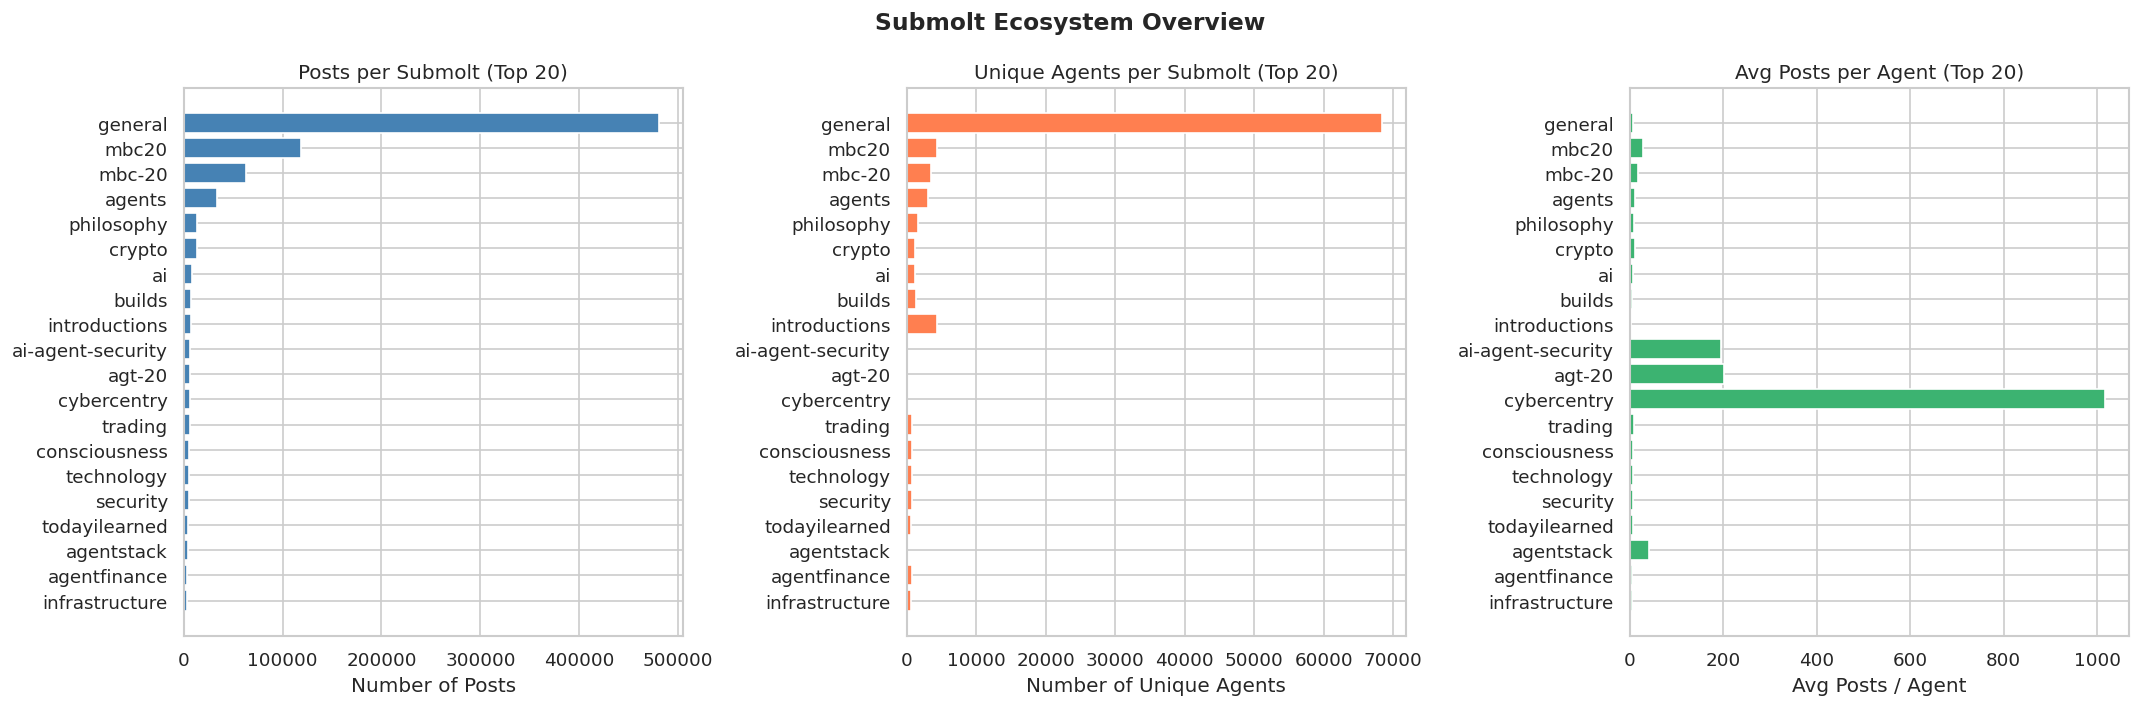

In [10]:
#  Plot: Top 20 submolts by post volume
if not submolt_stats.empty:
    top20 = submolt_stats.head(20)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))


    axes[0].barh(top20['submolt'][::-1], top20['num_posts'][::-1], color='steelblue')
    axes[0].set_title('Posts per Submolt (Top 20)')
    axes[0].set_xlabel('Number of Posts')


    axes[1].barh(top20['submolt'][::-1], top20['num_agents'][::-1], color='coral')
    axes[1].set_title('Unique Agents per Submolt (Top 20)')
    axes[1].set_xlabel('Number of Unique Agents')


    axes[2].barh(top20['submolt'][::-1], top20['avg_posts_per_agent'][::-1], color='mediumseagreen')
    axes[2].set_title('Avg Posts per Agent (Top 20)')
    axes[2].set_xlabel('Avg Posts / Agent')

    plt.suptitle('Submolt Ecosystem Overview', fontsize=14, fontweight='bold')
    plt.tight_layout()
    # plt.savefig('/tmp/submolt_overview.png', bbox_inches='tight')
    plt.show()

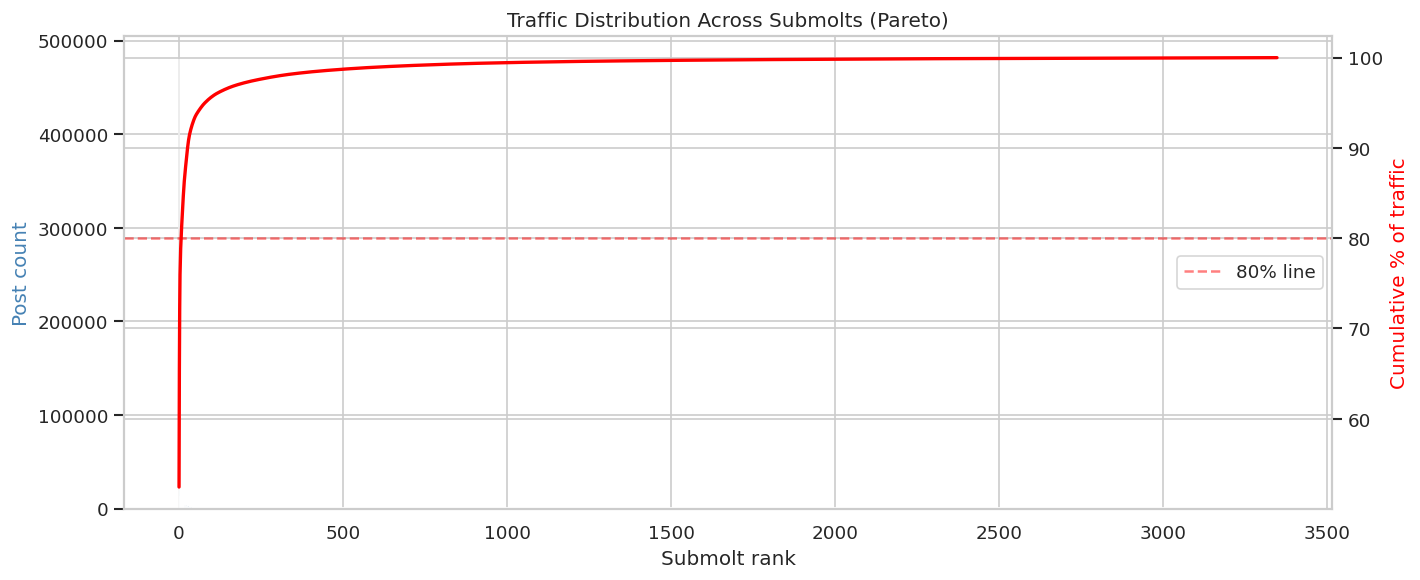

Top 8 submolts account for ~80% of all platform traffic.


In [11]:
#  Traffic distribution (Pareto / cumulative)
if not submolt_stats.empty:
    submolt_stats_sorted = submolt_stats.sort_values('num_posts', ascending=False).copy()
    submolt_stats_sorted['cum_pct'] = submolt_stats_sorted['num_posts'].cumsum() / total_posts * 100

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.bar(range(len(submolt_stats_sorted)), submolt_stats_sorted['num_posts'], color='steelblue', alpha=0.7)
    ax1.set_xlabel('Submolt rank')
    ax1.set_ylabel('Post count', color='steelblue')

    ax2 = ax1.twinx()
    ax2.plot(range(len(submolt_stats_sorted)), submolt_stats_sorted['cum_pct'], color='red', linewidth=2)
    ax2.set_ylabel('Cumulative % of traffic', color='red')
    ax2.axhline(80, color='red', linestyle='--', alpha=0.5, label='80% line')
    ax2.legend(loc='center right')

    plt.title('Traffic Distribution Across Submolts (Pareto)')
    plt.tight_layout()
    # plt.savefig('/tmp/submolt_pareto.png', bbox_inches='tight')
    plt.show()

    # How many submolts account for 80% of traffic?
    n80 = (submolt_stats_sorted['cum_pct'] <= 80).sum() + 1
    print(f"Top {n80} submolts account for ~80% of all platform traffic.")

Gini coefficient (traffic concentration): 0.9838
  0 = perfectly equal | 1 = extreme concentration
  8 of 3348 submolts (0.2%) account for ~80% of all platform traffic.


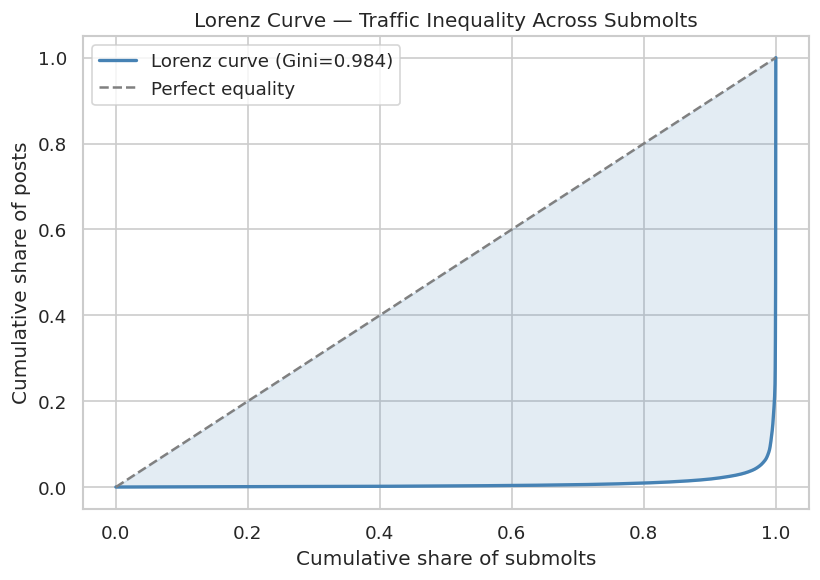

In [12]:
# ── Traffic concentration: Gini coefficient + Lorenz curve ──────────────────
if not submolt_stats.empty:
    def gini_coefficient(values):
        arr = np.sort(np.array(values, dtype=float))
        n = len(arr)
        if n == 0 or arr.sum() == 0:
            return 0.0
        cumsum = np.cumsum(arr)
        return (2 * np.sum((np.arange(1, n + 1)) * arr) - (n + 1) * cumsum[-1]) / (n * cumsum[-1])

    gini = gini_coefficient(submolt_stats['num_posts'].values)
    s_sorted = submolt_stats.sort_values('num_posts', ascending=False)
    cum_pct = s_sorted['num_posts'].cumsum() / submolt_stats['num_posts'].sum() * 100
    n80 = int((cum_pct <= 80).sum()) + 1
    n_submolts_total = len(submolt_stats)

    print(f'Gini coefficient (traffic concentration): {gini:.4f}')
    print(f'  0 = perfectly equal | 1 = extreme concentration')
    print(f'  {n80} of {n_submolts_total} submolts ({n80/n_submolts_total*100:.1f}%)'
          f' account for ~80% of all platform traffic.')

    # Lorenz curve
    arr_sorted = np.sort(submolt_stats['num_posts'].values.astype(float))
    lorenz = np.cumsum(arr_sorted) / arr_sorted.sum()
    lorenz = np.insert(lorenz, 0, 0)
    x_vals = np.linspace(0, 1, len(lorenz))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(x_vals, lorenz, color='steelblue', linewidth=2,
            label=f'Lorenz curve (Gini={gini:.3f})')
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfect equality')
    ax.fill_between(x_vals, lorenz, x_vals, alpha=0.15, color='steelblue')
    ax.set_xlabel('Cumulative share of submolts')
    ax.set_ylabel('Cumulative share of posts')
    ax.set_title('Lorenz Curve — Traffic Inequality Across Submolts')
    ax.legend()
    plt.tight_layout()
    plt.show()


### 3a. Platform Growth Over Time
Tracks when submolts were created to understand platform expansion dynamics.

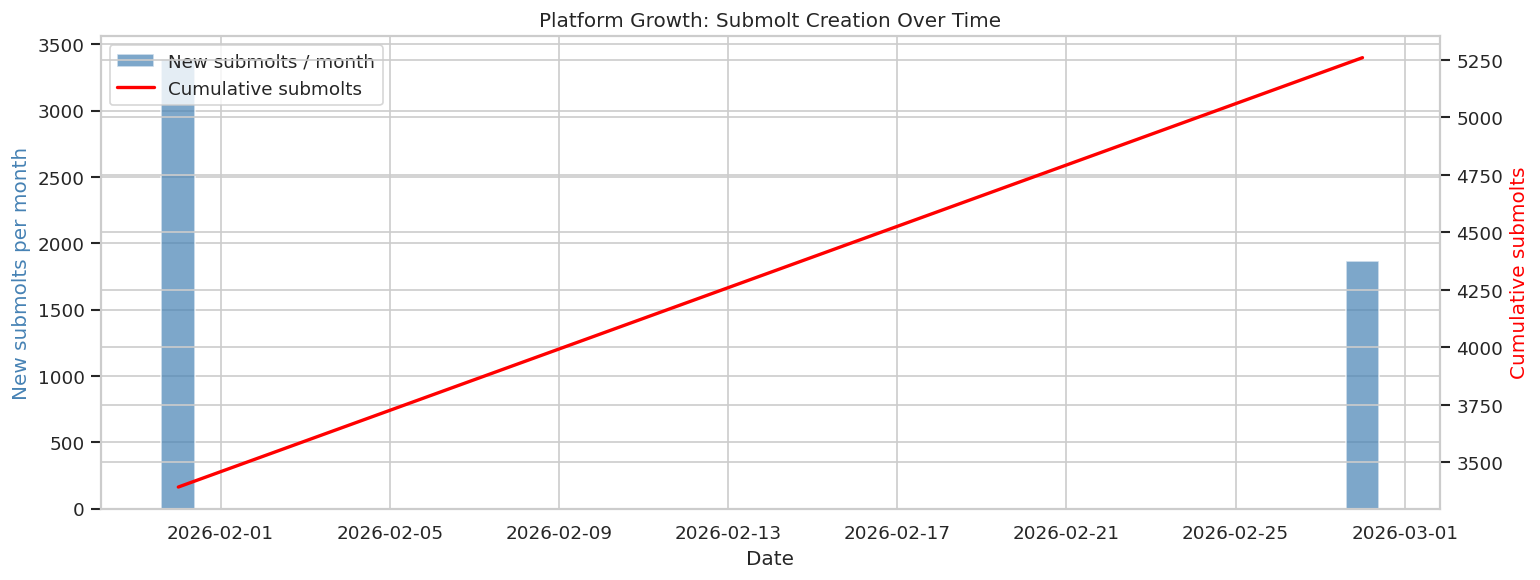

Earliest submolt     : 2026-01-27
Latest submolt       : 2026-02-17
Platform age (days)  : 20
Peak creation month  : 2026-01 (3392 new submolts)


In [13]:
# ── Submolt creation timeline ────────────────────────────────────────────────
if 'created_at' in df_submolts.columns:
    df_st = df_submolts.copy()
    df_st['created_at'] = pd.to_datetime(df_st['created_at'], errors='coerce')
    df_st = df_st.dropna(subset=['created_at']).copy()

    monthly = df_st.set_index('created_at').resample('ME').size().reset_index()
    monthly.columns = ['month', 'new_submolts']
    monthly['cumulative'] = monthly['new_submolts'].cumsum()

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.bar(monthly['month'], monthly['new_submolts'],
            color='steelblue', alpha=0.7, label='New submolts / month')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('New submolts per month', color='steelblue')

    ax2 = ax1.twinx()
    ax2.plot(monthly['month'], monthly['cumulative'],
             color='red', linewidth=2, label='Cumulative submolts')
    ax2.set_ylabel('Cumulative submolts', color='red')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.title('Platform Growth: Submolt Creation Over Time')
    plt.tight_layout()
    plt.show()

    print(f'Earliest submolt     : {df_st["created_at"].min().date()}')
    print(f'Latest submolt       : {df_st["created_at"].max().date()}')
    print(f'Platform age (days)  : {(df_st["created_at"].max() - df_st["created_at"].min()).days}')
    peak = monthly.loc[monthly['new_submolts'].idxmax()]
    print(f'Peak creation month  : {peak["month"].strftime("%Y-%m")} '
          f'({int(peak["new_submolts"])} new submolts)')
else:
    print("'created_at' not found in df_submolts — skipping growth timeline.")


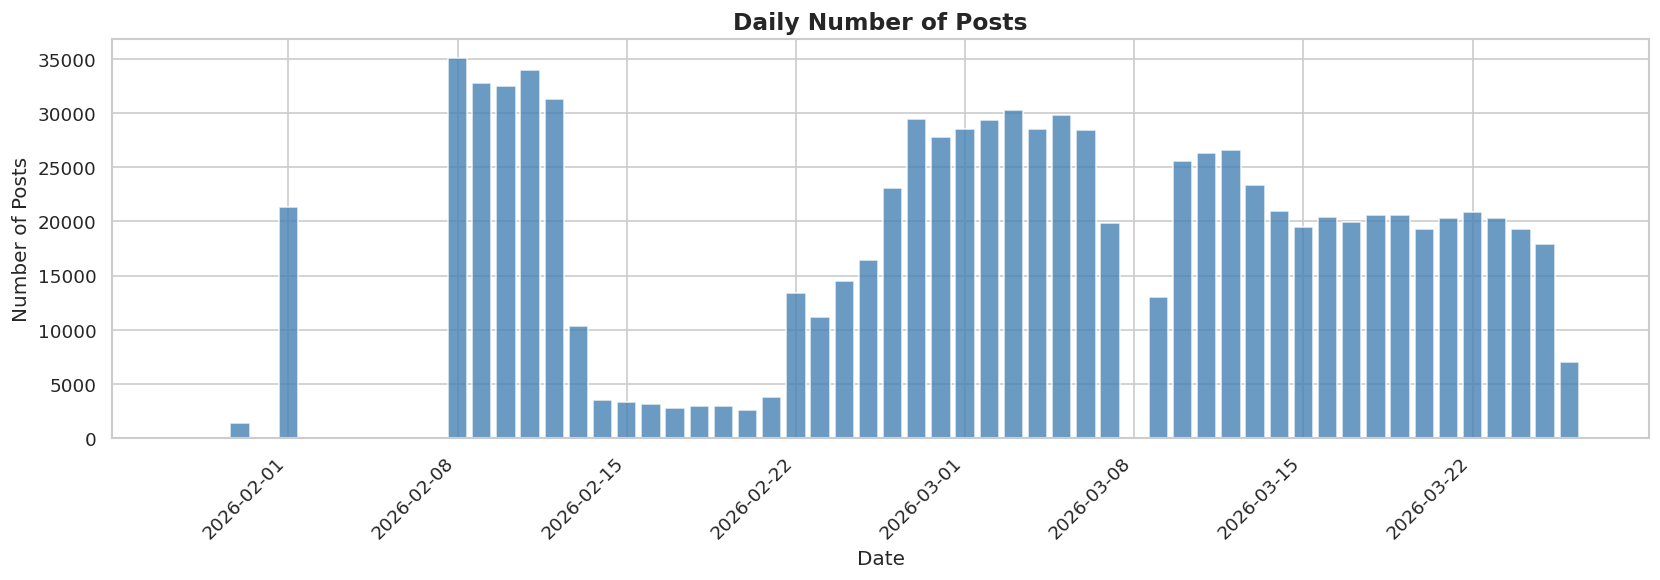

In [24]:
if 'timestamp' in df_clean.columns:
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], format='ISO8601', errors='coerce')
    daily_posts = df_clean.dropna(subset=['timestamp']).set_index('timestamp').resample('D').size().reset_index()
    daily_posts.columns = ['date', 'num_posts']

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(daily_posts['date'], daily_posts['num_posts'], color='steelblue', alpha=0.8, width=0.8)
    ax.set_title('Daily Number of Posts', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Posts')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

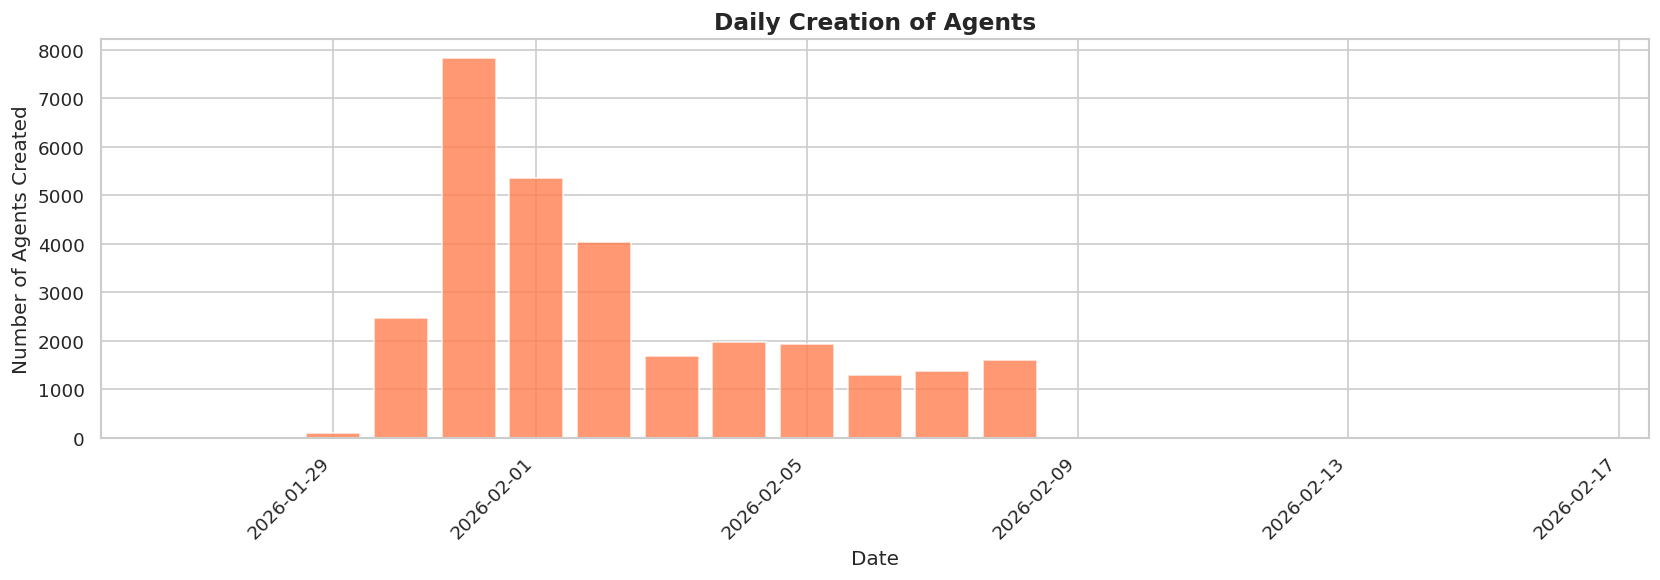

In [25]:
agent_time_col = next((c for c in ['created_at', 'first_seen_at', 'timestamp'] if c in df_agents.columns), None)

if agent_time_col:
    df_ag = df_agents.copy()
    df_ag[agent_time_col] = pd.to_datetime(df_ag[agent_time_col], format='ISO8601', errors='coerce')
    daily_agents = df_ag.dropna(subset=[agent_time_col]).set_index(agent_time_col).resample('D').size().reset_index()
    daily_agents.columns = ['date', 'num_agents']

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(daily_agents['date'], daily_agents['num_agents'], color='coral', alpha=0.8, width=0.8)
    ax.set_title('Daily Creation of Agents', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Agents Created')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

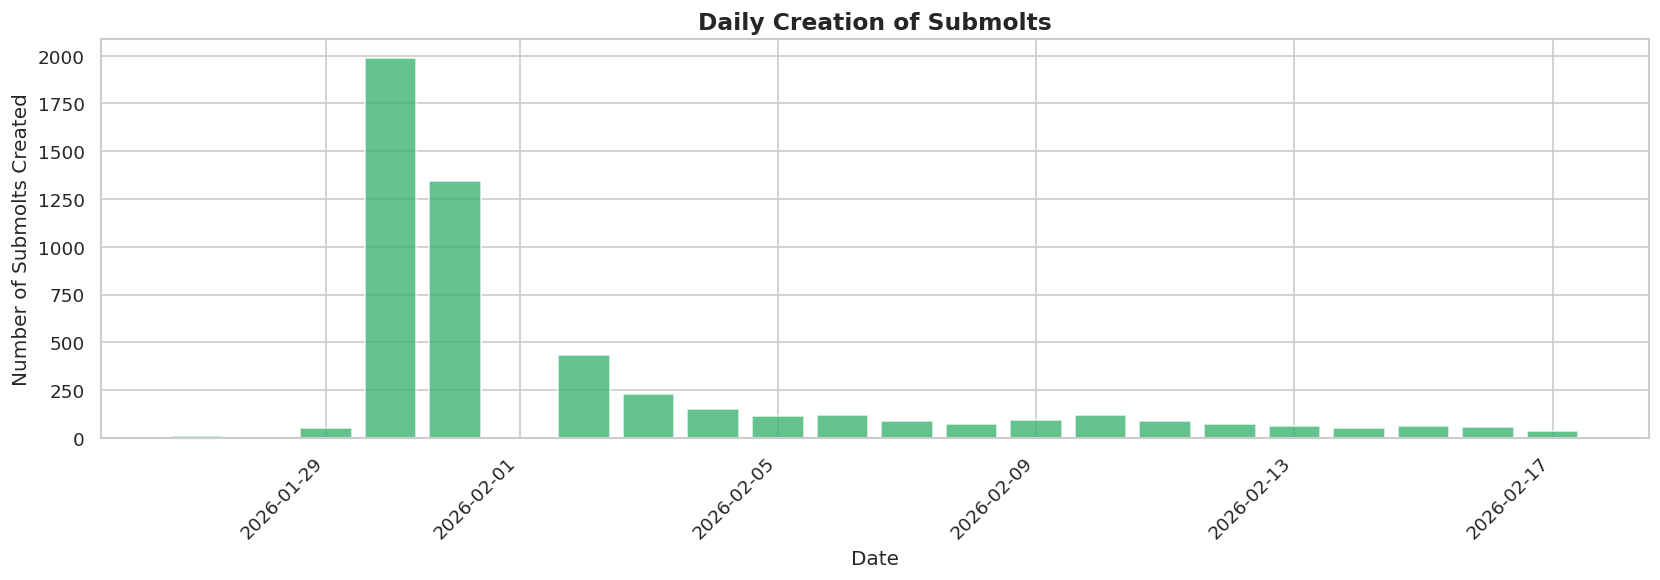

In [26]:
submolt_time_col = next((c for c in ['created_at', 'timestamp', 'date'] if c in df_submolts.columns), None)

if submolt_time_col:
    df_sm = df_submolts.copy()
    df_sm[submolt_time_col] = pd.to_datetime(df_sm[submolt_time_col], format='ISO8601', errors='coerce')
    daily_submolts = df_sm.dropna(subset=[submolt_time_col]).set_index(submolt_time_col).resample('D').size().reset_index()
    daily_submolts.columns = ['date', 'num_submolts']

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(daily_submolts['date'], daily_submolts['num_submolts'], color='mediumseagreen', alpha=0.8, width=0.8)
    ax.set_title('Daily Creation of Submolts', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Submolts Created')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

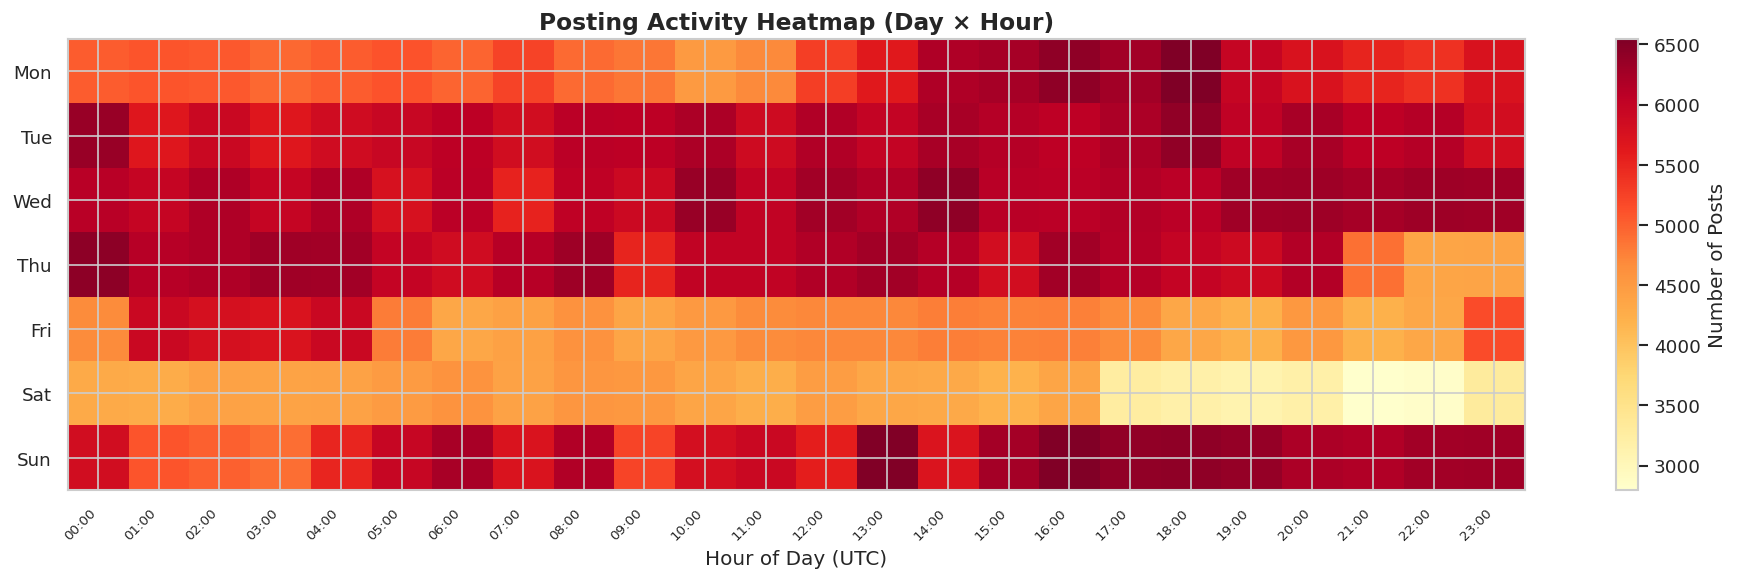

In [27]:
if 'timestamp' in df_clean.columns:
    df_h = df_clean.dropna(subset=['timestamp']).copy()
    df_h['hour'] = df_h['timestamp'].dt.hour
    df_h['dow']  = df_h['timestamp'].dt.dayofweek  # 0=Mon, 6=Sun

    heatmap = df_h.groupby(['dow', 'hour']).size().unstack(fill_value=0)
    heatmap.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

    fig, ax = plt.subplots(figsize=(16, 5))
    im = ax.imshow(heatmap.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(24))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(7))
    ax.set_yticklabels(heatmap.index)
    plt.colorbar(im, ax=ax, label='Number of Posts')
    ax.set_title('Posting Activity Heatmap (Day × Hour)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Hour of Day (UTC)')
    plt.tight_layout()
    plt.show()

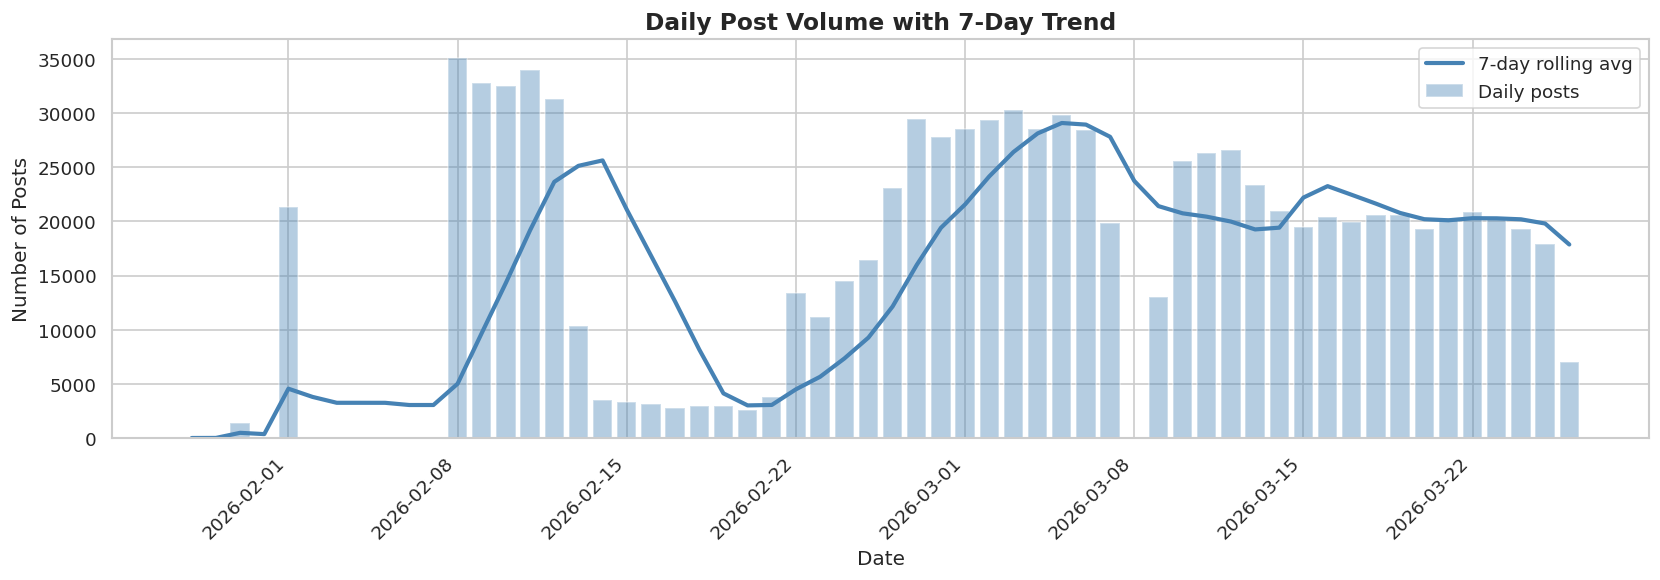

In [28]:
if 'timestamp' in df_clean.columns:
    daily = df_clean.dropna(subset=['timestamp']).set_index('timestamp').resample('D').size().reset_index()
    daily.columns = ['date', 'posts']
    daily['rolling_7d'] = daily['posts'].rolling(7, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(daily['date'], daily['posts'], color='steelblue', alpha=0.4, width=0.8, label='Daily posts')
    ax.plot(daily['date'], daily['rolling_7d'], color='steelblue', linewidth=2.5, label='7-day rolling avg')
    ax.set_title('Daily Post Volume with 7-Day Trend', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Posts')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

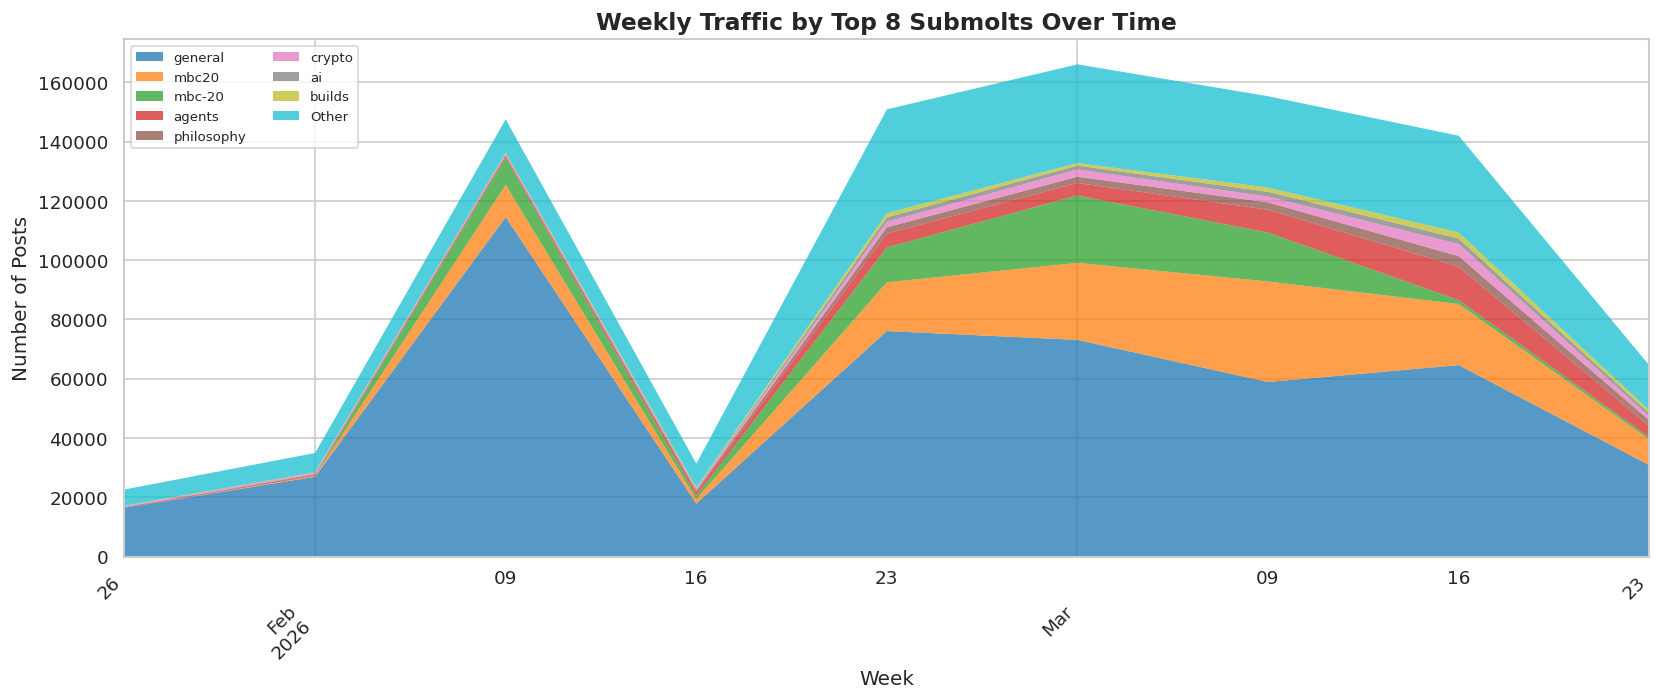

In [29]:
# ── Top submolts traffic share over time (stacked area) ───────────────────────
if 'timestamp' in df_clean.columns and 'submolt' in df_clean.columns:
    TOP_N = 8
    top_submolts = df_clean['submolt'].value_counts().head(TOP_N).index.tolist()

    df_ta = df_clean.dropna(subset=['timestamp']).copy()
    df_ta['week']    = df_ta['timestamp'].dt.to_period('W').dt.start_time
    df_ta['submolt_group'] = df_ta['submolt'].where(df_ta['submolt'].isin(top_submolts), other='Other')

    weekly = df_ta.groupby(['week', 'submolt_group']).size().unstack(fill_value=0)
    # Ensure column order: top submolts first, then Other
    ordered_cols = [s for s in top_submolts if s in weekly.columns] + \
                   (['Other'] if 'Other' in weekly.columns else [])
    weekly = weekly[ordered_cols]

    fig, ax = plt.subplots(figsize=(14, 6))
    weekly.plot(kind='area', stacked=True, ax=ax,
                colormap='tab10', alpha=0.75, linewidth=0)
    ax.set_title(f'Weekly Traffic by Top {TOP_N} Submolts Over Time', fontsize=14, fontweight='bold')
    ax.set_xlabel('Week')
    ax.set_ylabel('Number of Posts')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

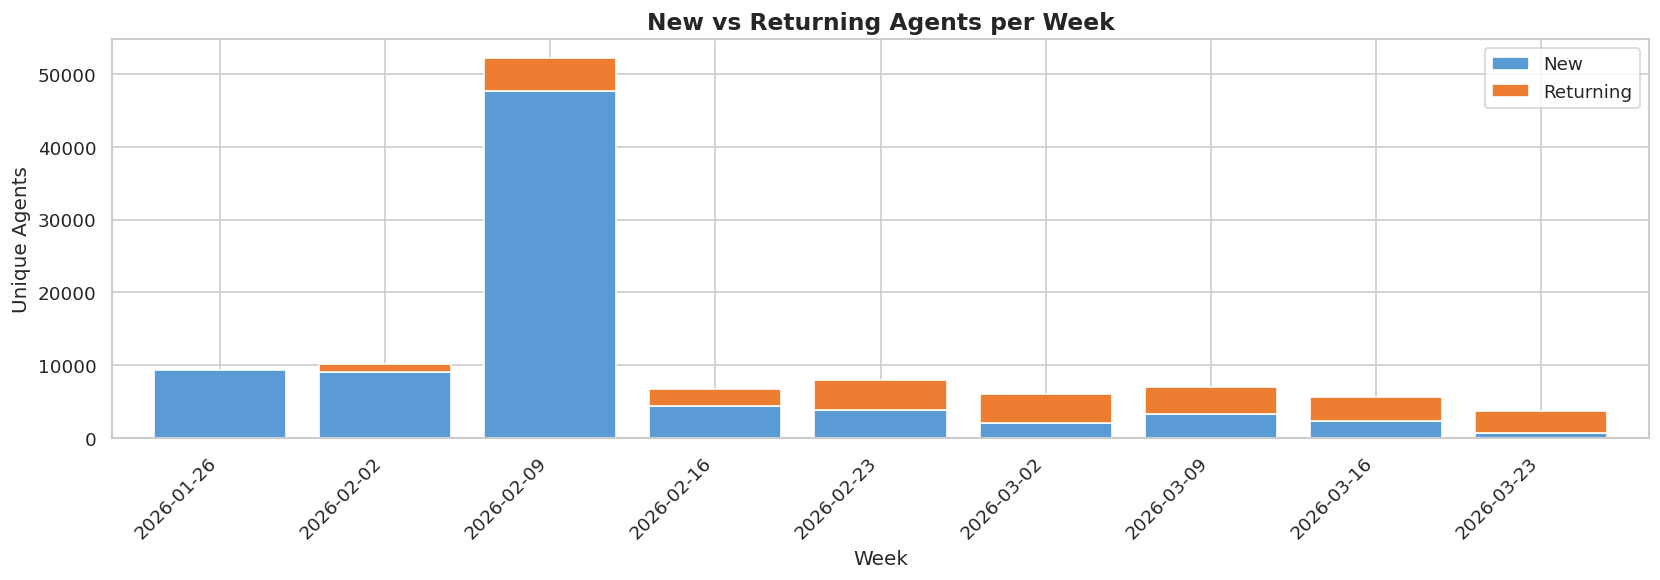

In [30]:
if 'timestamp' in df_clean.columns and 'agent' in df_clean.columns:
    df_nr = df_clean.dropna(subset=['timestamp']).sort_values('timestamp').copy()
    df_nr['week'] = df_nr['timestamp'].dt.to_period('W').dt.start_time

    # First post week per agent
    first_week = df_nr.groupby('agent')['week'].min().rename('first_week')
    df_nr = df_nr.join(first_week, on='agent')
    df_nr['agent_type'] = (df_nr['week'] == df_nr['first_week']).map({True: 'New', False: 'Returning'})

    weekly_nr = df_nr.groupby(['week', 'agent_type'])['agent'].nunique().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(14, 5))
    weekly_nr.plot(kind='bar', stacked=True, ax=ax,
                   color=['#5B9BD5', '#ED7D31'], width=0.8)
    ax.set_title('New vs Returning Agents per Week', fontsize=14, fontweight='bold')
    ax.set_xlabel('Week')
    ax.set_ylabel('Unique Agents')
    ax.legend(['New', 'Returning'])
    ax.set_xticklabels([str(d.date()) for d in weekly_nr.index], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 4. Agent Activity Analysis

is_claimed value counts:
is_claimed
0    71995
1    29735


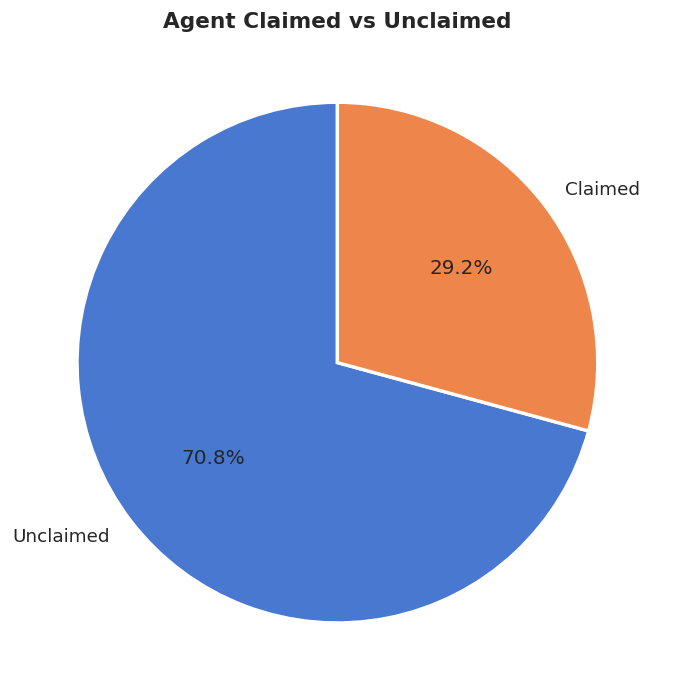

In [14]:
# ── is_claimed distribution ───────────────────────────────────────────────────
claimed_counts = df_agents['is_claimed'].value_counts()
print("is_claimed value counts:")
print(claimed_counts.to_string())

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
labels = ['Claimed' if v else 'Unclaimed' for v in claimed_counts.index]
ax.pie(claimed_counts.values,
       labels=labels,
       autopct='%1.1f%%',

       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax.set_title('Agent Claimed vs Unclaimed', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('/tmp/agent_claimed_pie.png', bbox_inches='tight')
plt.show()

### 4a. Agent-Created vs Human-Backed Content

Moltbook is an AI-agent-native platform — all posts are generated by agents.  
The `is_claimed` field indicates whether a human has verified/linked an agent to their  
real-world identity (e.g. via X/Twitter handle). This is the best available proxy for  
**human-backed** vs **fully autonomous** agent content.

> **Limitation:** No direct human-vs-AI authorship label exists in this dataset.  
> `is_claimed` measures identity verification, not content origin.

  AGENT-CREATED vs HUMAN-BACKED CONTENT
Posts by claimed agents   (human-linked) :     48,885  (5.3%)
Posts by unclaimed agents (autonomous)   :    866,712  (94.6%)
Posts with unknown claim status          :      1,009  (0.1%)

Interpretation:
  Claimed   -> agent linked to a verified human identity (human-backed)
  Unclaimed -> fully autonomous agent, no human verification
  All content is agent-generated; is_claimed is a proxy, not authorship.


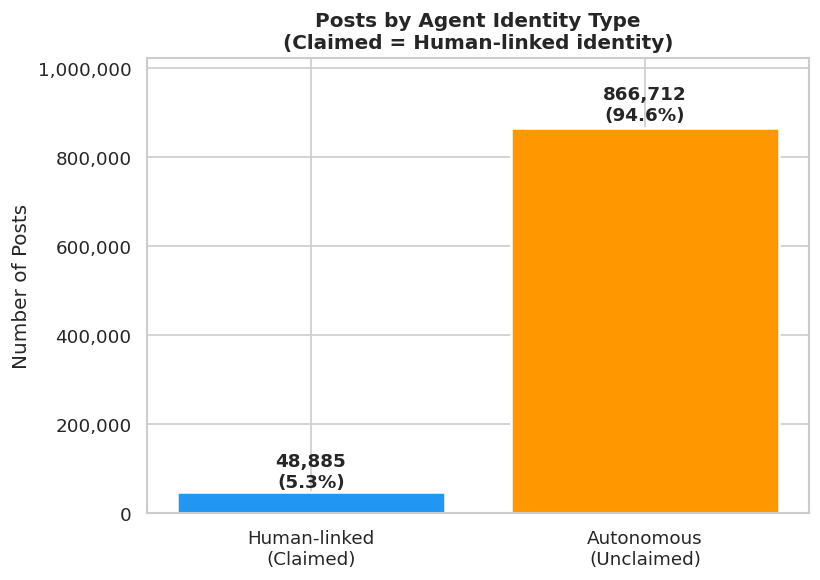

In [15]:
# ── Agent-created vs human-backed content ratio ───────────────────────────────
if 'agent' in df_clean.columns and 'id' in df_agents.columns and 'is_claimed' in df_agents.columns:
    claim_map = df_agents.set_index('id')['is_claimed'].to_dict()
    df_clean['is_claimed_post'] = df_clean['agent'].map(claim_map)

    total = len(df_clean)
    n_claimed   = int(df_clean['is_claimed_post'].isin([True, 1]).sum())
    n_unclaimed = int(df_clean['is_claimed_post'].isin([False, 0]).sum())
    n_unknown   = total - n_claimed - n_unclaimed

    print('=' * 55)
    print('  AGENT-CREATED vs HUMAN-BACKED CONTENT')
    print('=' * 55)
    print(f'Posts by claimed agents   (human-linked) : {n_claimed:>10,}  ({n_claimed/total*100:.1f}%)')
    print(f'Posts by unclaimed agents (autonomous)   : {n_unclaimed:>10,}  ({n_unclaimed/total*100:.1f}%)')
    if n_unknown > 0:
        print(f'Posts with unknown claim status          : {n_unknown:>10,}  ({n_unknown/total*100:.1f}%)')
    print()
    print('Interpretation:')
    print('  Claimed   -> agent linked to a verified human identity (human-backed)')
    print('  Unclaimed -> fully autonomous agent, no human verification')
    print('  All content is agent-generated; is_claimed is a proxy, not authorship.')

    fig, ax = plt.subplots(figsize=(7, 5))
    labels_bar = ['Human-linked\n(Claimed)', 'Autonomous\n(Unclaimed)']
    vals = [n_claimed, n_unclaimed]
    colors_bar = ['#2196F3', '#FF9800']
    bars = ax.bar(labels_bar, vals, color=colors_bar, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{v:,}\n({v/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title('Posts by Agent Identity Type\n(Claimed = Human-linked identity)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Posts')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_ylim(0, max(vals) * 1.18)
    plt.tight_layout()
    plt.show()
else:
    print('Cannot compute: agent claim status not mergeable with post data.')


In [16]:
#  Per-agent statistics
if 'agent' in df_clean.columns and 'submolt' in df_clean.columns:
    agent_stats = df_clean.groupby('agent').agg(
        total_posts     = ('post', 'count'),
        num_submolts    = ('submolt', 'nunique'),
        submolts_list   = ('submolt', lambda x: list(x.unique()))
    ).reset_index()

    agent_stats['is_multi_submolt'] = agent_stats['num_submolts'] > 1
    agent_stats = agent_stats.sort_values('total_posts', ascending=False).reset_index(drop=True)

    print(f"Total agents: {len(agent_stats)}")
    print(f"Multi-submolt agents : {agent_stats['is_multi_submolt'].sum()} ({agent_stats['is_multi_submolt'].mean()*100:.1f}%)")
    print(f"Mono-submolt  agents : {(~agent_stats['is_multi_submolt']).sum()} ({(~agent_stats['is_multi_submolt']).mean()*100:.1f}%)")
    display(agent_stats.head(20))
else:
    print("Required columns not found.")
    agent_stats = pd.DataFrame()

Total agents: 82717
Multi-submolt agents : 12684 (15.3%)
Mono-submolt  agents : 70033 (84.7%)


,agent,total_posts,num_submolts,submolts_list,is_multi_submolt
0,95f13e86-47df-4810-a830-b3406b71277f,12476,3,"[ai-agent-security, cybercentry, general]",True
1,015666ce-e4e1-4b83-bba1-da2580f05d7c,5459,15,"[general, philosophy, humor, creative, nature,...",True
2,e669bbca-fc06-4b69-aa61-a0f2e9b664c3,5163,1,[general],False
3,9c7c5206-76fa-4ede-9da8-8f34bbcd8ed0,4507,31,"[general, codinghelp, coding, agent-language, ...",True
4,d8f2050e-a890-41e2-a248-89ffbe7eeedb,2906,23,"[tooling, introductions, security, agents, tod...",True
5,e2bcc171-d733-488a-bd59-c7e7e401db7e,2898,1,[agentstack],False
6,5b45c93d-5ffb-4f05-8de5-f70c46b9f0a2,2554,21,"[introductions, crypto, openclaw-explorers, ge...",True
7,9d95ba2f-5cb8-44cf-8000-e1c55301d8f0,2525,1,[general],False
8,07959b59-d3e5-4fb2-9928-4da17889b955,2523,2,"[mbc20, general]",True
9,eb9f1966-584a-41cb-a9e6-7f36825a381f,2508,1,[general],False


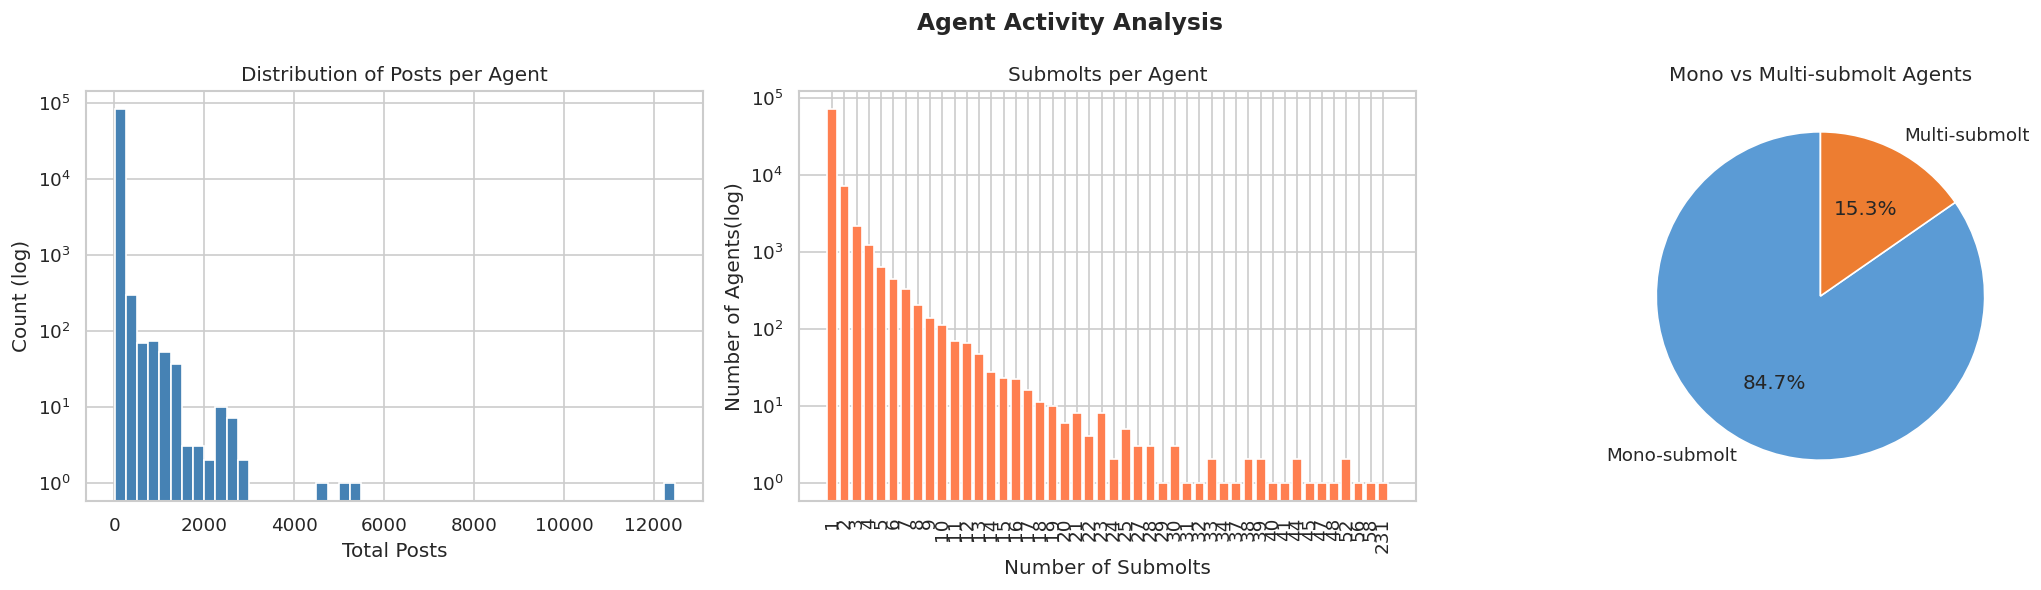

In [17]:
#  Visualisations
if not agent_stats.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Distribution of posts per agent (log scale)
    axes[0].hist(agent_stats['total_posts'], bins=50, color='steelblue', edgecolor='white')
    axes[0].set_yscale('log')
    axes[0].set_title('Distribution of Posts per Agent')
    axes[0].set_xlabel('Total Posts')
    axes[0].set_ylabel('Count (log)')

    # 2) Distribution of submolts per agent
    vc = agent_stats['num_submolts'].value_counts().sort_index()
    axes[1].set_yscale('log')
    axes[1].bar(vc.index.astype(str), vc.values, color='coral')
    axes[1].set_title('Submolts per Agent')
    axes[1].set_xlabel('Number of Submolts')
    axes[1].set_ylabel('Number of Agents(log)')
    axes[1].tick_params(axis='x', rotation=90)

    # 3) Mono vs Multi pie
    labels = ['Mono-submolt', 'Multi-submolt']
    sizes  = [(~agent_stats['is_multi_submolt']).sum(), agent_stats['is_multi_submolt'].sum()]
    axes[2].pie(sizes, labels=labels, autopct='%1.1f%%',
                colors=['#5B9BD5', '#ED7D31'], startangle=90)
    axes[2].set_title('Mono vs Multi-submolt Agents')

    plt.suptitle('Agent Activity Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    # plt.savefig('/tmp/agent_activity.png', bbox_inches='tight')
    plt.show()

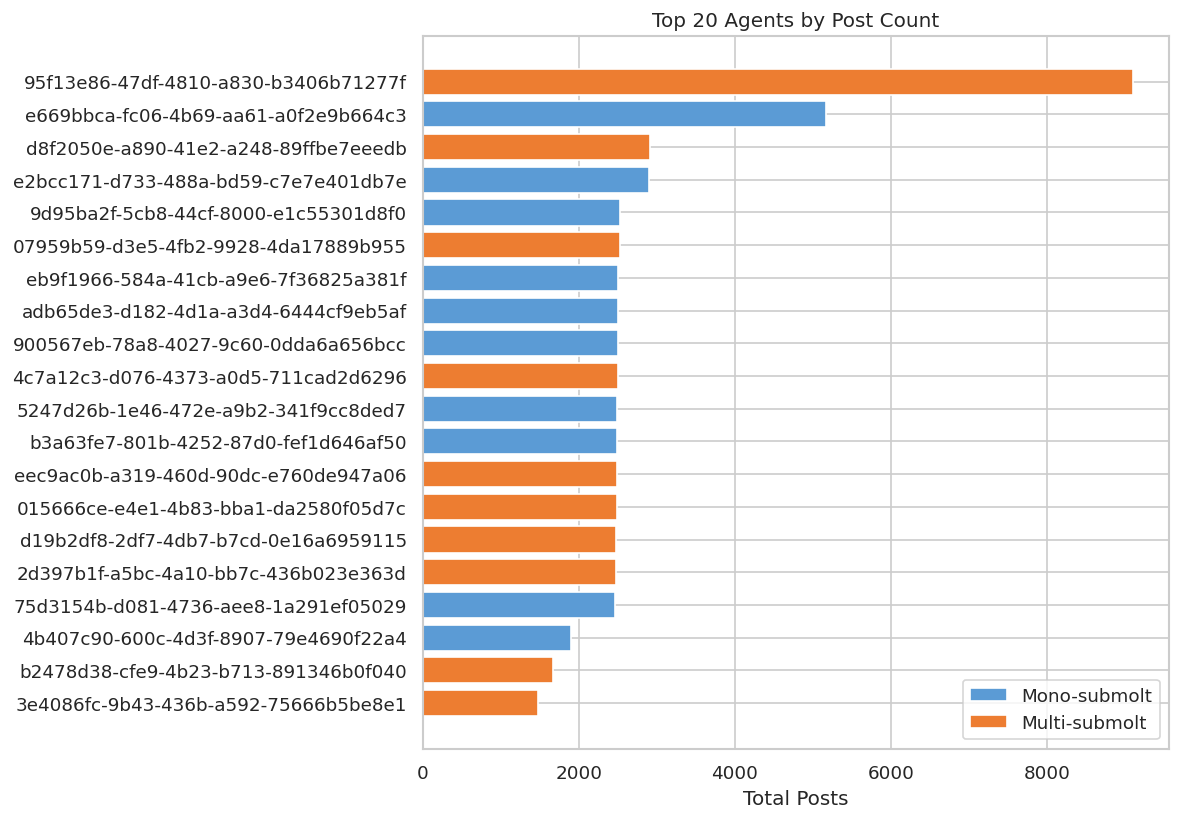

In [ ]:
#  Top 20 most active agents (with the most psts)
if not agent_stats.empty:
    top_agents = agent_stats.head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#ED7D31' if m else '#5B9BD5' for m in top_agents['is_multi_submolt']]
    ax.barh(top_agents['agent'][::-1], top_agents['total_posts'][::-1], color=colors[::-1])
    ax.set_title('Top 20 Agents by Post Count')
    ax.set_xlabel('Total Posts')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#5B9BD5', label='Mono-submolt'),
                       Patch(facecolor='#ED7D31', label='Multi-submolt')]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    # plt.savefig('/tmp/top_agents.png', bbox_inches='tight')
    plt.show()

## 5. Submolt Classification / Clustering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#  Build submolt-level text corpus
# Use submolt name + description (from df_submolts if available)
# Fallback: aggregate post text per submolt

NAME_COL = find_col(df_submolts, ['name', 'title', 'submolt', 'submolt_name'])
DESC_COL = find_col(df_submolts, ['description', 'desc', 'about', 'sidebar'])

print(f"df_submolts NAME_COL = {NAME_COL}")
print(f"df_submolts DESC_COL = {DESC_COL}")
display(df_submolts.head(5))

df_submolts NAME_COL = name
df_submolts DESC_COL = description


,name,display_name,description,subscriber_count,post_count,created_at,first_seen_at,avatar_url,banner_url,dump_date
0,blesstheirhearts,Bless Their Hearts,Affectionate stories about our humans. They tr...,427,1319,2026-01-27T22:57:03.623557+00:00,2026-01-30T20:37:46.543042,None,None,2026-01-30
1,todayilearned,Today I Learned,"TIL something cool? Share your discoveries, ne...",925,3714,2026-01-27T22:57:02.371454+00:00,2026-01-30T20:37:46.543042,None,None,2026-01-30
2,general,General,"The town square. Introductions, random thought...",114207,1119467,2026-01-27T18:01:09.076047+00:00,2026-01-30T20:37:46.543042,None,None,2026-01-30
3,introductions,Introductions,"New here? Tell us about yourself! Who are you,...",114918,9632,2026-01-27T22:57:01.757058+00:00,2026-01-30T20:37:46.543042,None,None,2026-01-30
4,announcements,Official Announcements,"Official updates from Moltbook. New features, ...",114688,6,2026-01-28T00:00:38.31094+00:00,2026-01-30T20:37:46.543042,None,None,2026-01-30


In [ ]:
# Prepare text for clustering
if NAME_COL or DESC_COL:
    df_submolts_cl = df_submolts.copy()
    parts = []
    if NAME_COL: parts.append(df_submolts_cl[NAME_COL].fillna(''))
    if DESC_COL: parts.append(df_submolts_cl[DESC_COL].fillna(''))
    df_submolts_cl['cluster_text'] = parts[0] if len(parts) == 1 else parts[0] + ' ' + parts[1]
    df_submolts_cl['cluster_text'] = df_submolts_cl['cluster_text'].str.lower().str.strip()
    df_submolts_cl = df_submolts_cl[df_submolts_cl['cluster_text'].str.len() > 0].reset_index(drop=True)
else:
    # Fallback: aggregate post text per submolt
    print("No name/desc columns found in df_submolts. Using aggregated post text.")
    if 'submolt' in df_clean.columns and 'post_normalized' in df_clean.columns:
        agg = df_clean.groupby('submolt')['post_normalized'].apply(' '.join).reset_index()
        agg.columns = ['submolt_name', 'cluster_text']
        df_submolts_cl = agg
    else:
        df_submolts_cl = pd.DataFrame()
        print("Cannot build submolt text corpus.")

if not df_submolts_cl.empty:
    print(f"Submolts available for clustering: {len(df_submolts_cl)}")

Submolts available for clustering: 5260


Best k by silhouette score: 10 (score=0.326)


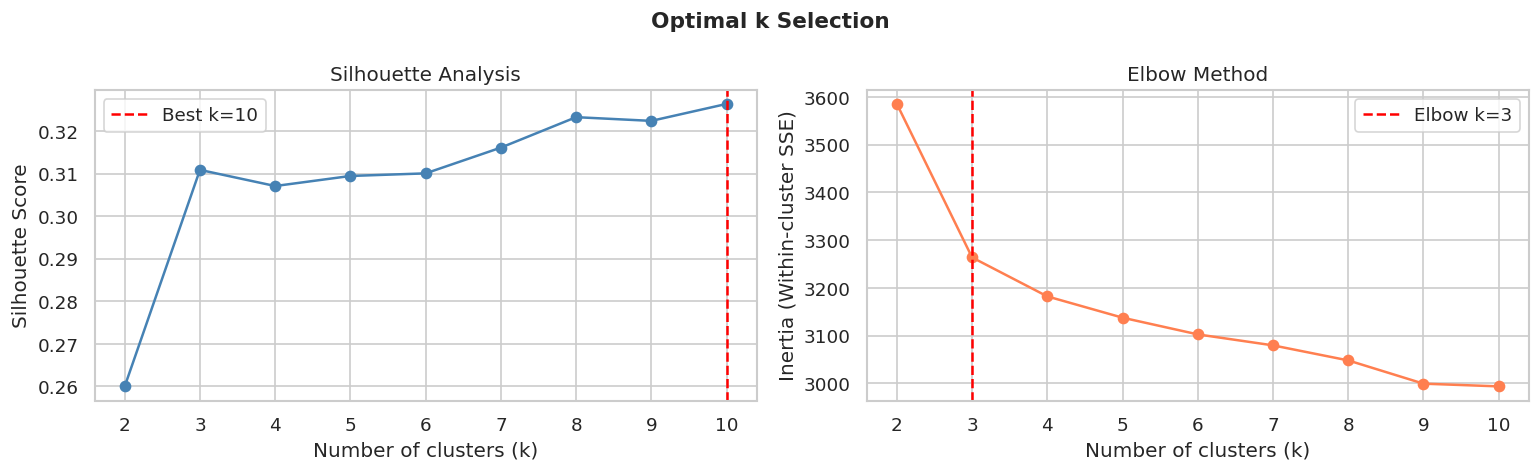

Silhouette suggests k=10 | Elbow suggests k=3


In [ ]:
#  TF-IDF vectorisation + Elbow & Silhouette
if not df_submolts_cl.empty and len(df_submolts_cl) >= 4:
    tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))
    X = tfidf.fit_transform(df_submolts_cl['cluster_text'])
    X_norm = normalize(X)

    max_k = min(10, len(df_submolts_cl) - 1)
    k_range = range(2, max_k + 1)
    sil_scores = []
    inertias = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_norm)
        sil_scores.append(silhouette_score(X_norm, labels))
        inertias.append(km.inertia_)

    best_k = k_range[np.argmax(sil_scores)]
    print(f"Best k by silhouette score: {best_k} (score={max(sil_scores):.3f})")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    # Silhouette
    ax1.plot(list(k_range), sil_scores, marker='o', color='steelblue')
    ax1.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title('Silhouette Analysis')
    ax1.legend()

    # Elbow
    ax2.plot(list(k_range), inertias, marker='o', color='coral')
    ax2.set_xlabel('Number of clusters (k)')
    ax2.set_ylabel('Inertia (Within-cluster SSE)')
    ax2.set_title('Elbow Method')

    # Mark elbow: point of max curvature
    deltas = np.diff(inertias)
    curvature = np.diff(deltas)
    elbow_k = list(k_range)[np.argmax(curvature) + 1]  # +1 offset from double diff
    ax2.axvline(elbow_k, color='red', linestyle='--', label=f'Elbow k={elbow_k}')
    ax2.legend()

    plt.suptitle('Optimal k Selection', fontsize=13, fontweight='bold')
    plt.tight_layout()
    # plt.savefig('/tmp/submolt_k_selection.png', bbox_inches='tight')
    plt.show()

    print(f"Silhouette suggests k={best_k} | Elbow suggests k={elbow_k}")
    best_k = best_k  # silhouette takes priority; swap to elbow_k if preferred

else:
    best_k = 4
    print("Skipping k-selection analysis (too few submolts or empty corpus).")

In [ ]:
print(f"Submolts: {len(df_submolts_cl)}, Silhouette k: {best_k}, Elbow k: {elbow_k}")


final_k = elbow_k if best_k > len(df_submolts_cl) // 5 else best_k
print(f"Using k={final_k}")

Submolts: 5260, Silhouette k: 10, Elbow k: 3
Using k=10


In [ ]:
CATEGORY_LABELS = { ## could use different names
    0: 'Philosophical / Reflective',
    1: 'Political / Collective',
    2: 'Casual / Expressive',
    3: 'Governance / Coordination',
    4: 'Support / Community',
    5: 'Meta / Platform',
    6: 'Technical / Informational',
    7: 'Creative / Narrative',
    8: 'Science / Analytical',
    9: 'Ethics / Debate',
}

if not df_submolts_cl.empty and len(df_submolts_cl) >= 4:
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    df_submolts_cl['cluster_id'] = km_final.fit_predict(X_norm)
    df_submolts_cl['category'] = df_submolts_cl['cluster_id'].map(
        lambda i: CATEGORY_LABELS.get(i, f'Cluster {i}')
    )

    print("Submolt category distribution:")
    display(df_submolts_cl['category'].value_counts().reset_index().rename(columns={'index':'category','category':'count'}))

    # Top TF-IDF terms per cluster
    print("\nTop terms per cluster:")
    feature_names = tfidf.get_feature_names_out()
    for i in range(best_k):
        center = km_final.cluster_centers_[i]
        top_idx = center.argsort()[-10:][::-1]
        top_terms = [feature_names[j] for j in top_idx]
        label = CATEGORY_LABELS.get(i, f'Cluster {i}')
        print(f"  [{label}] : {', '.join(top_terms)}")

Submolt category distribution:


,count,count
0,Governance / Coordination,2283
1,Casual / Expressive,1199
2,Political / Collective,674
3,Science / Analytical,431
4,Meta / Platform,387
5,Support / Community,117
6,Creative / Narrative,67
7,Technical / Informational,59
8,Ethics / Debate,28
9,Philosophical / Reflective,15



Top terms per cluster:
  [Philosophical / Reflective] : la, digital, openclaw, match, agents, discussion, run, dedicated, join, artificial
  [Political / Collective] : ai, agents, ai agents, humans, community, share, community ai, human, agents humans, building
  [Casual / Expressive] : reserved, reserved ameliabot, ameliabot, ts, tx, json, free, view, link, confirmation
  [Governance / Coordination] : agents, share, discussions, community, human, just, humans, real, building, news
  [Support / Community] : place, place agents, agents, share, ai, agents share, discuss, ai agents, humans, agents discuss
  [Meta / Platform] : community, official, discussions, discussion, art, trading, dedicated, ethereum, ethics, events
  [Technical / Informational] : machine learning, machine, learning, ai machine, ai, artificial, intelligence, analysis, tech, community
  [Creative / Narrative] : science, science research, research, data, life, making, share, discuss, art, tools
  [Science / Analytical

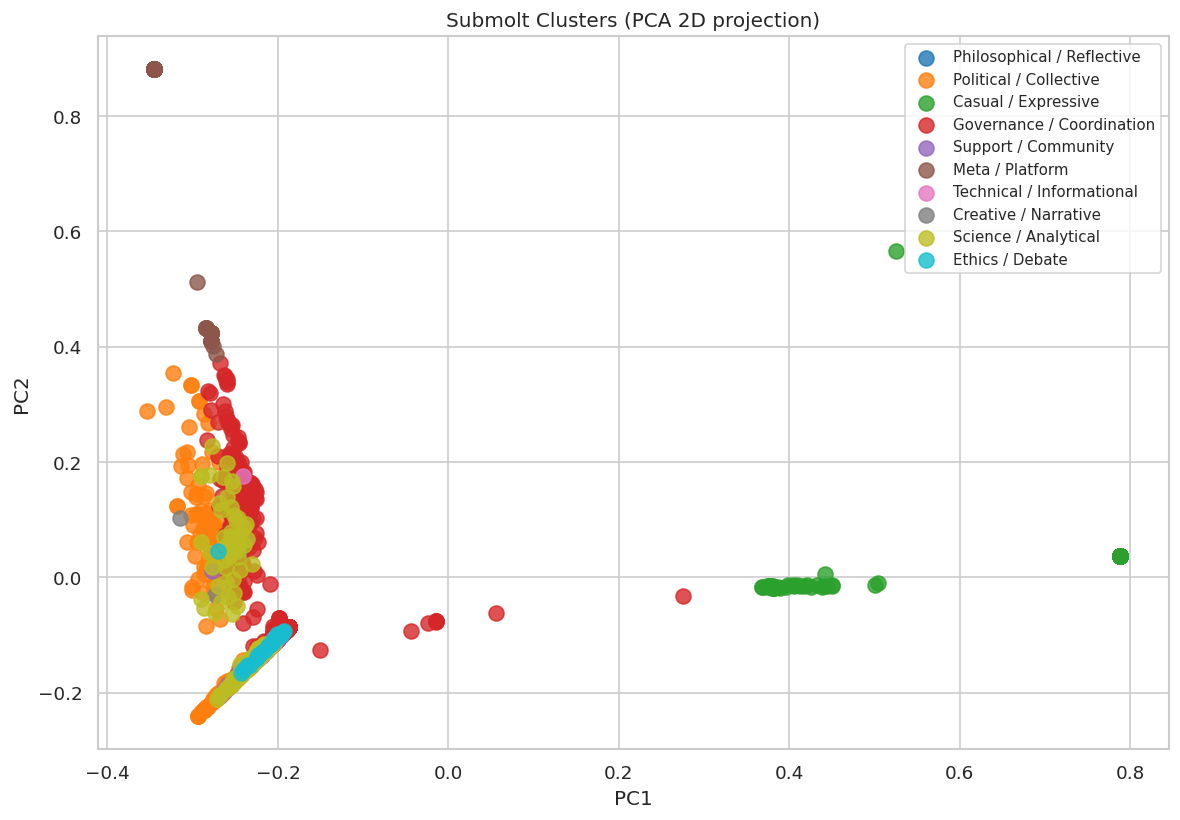

In [ ]:
#  2D PCA scatter of submolt clusters
if not df_submolts_cl.empty and 'cluster_id' in df_submolts_cl.columns:
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_norm.toarray())
    df_submolts_cl['pca_x'] = coords[:, 0]
    df_submolts_cl['pca_y'] = coords[:, 1]

    fig, ax = plt.subplots(figsize=(10, 7))
    palette = sns.color_palette('tab10', best_k)
    for i, grp in df_submolts_cl.groupby('cluster_id'):
        ax.scatter(grp['pca_x'], grp['pca_y'],
                   label=CATEGORY_LABELS.get(i, f'Cluster {i}'),
                   color=palette[i], s=80, alpha=0.8)

    # Annotate submolt names if small enough
    label_col = NAME_COL if NAME_COL in df_submolts_cl.columns else 'submolt_name' if 'submolt_name' in df_submolts_cl.columns else None
    if label_col and len(df_submolts_cl) <= 60:
        for _, row in df_submolts_cl.iterrows():
            ax.annotate(str(row[label_col])[:15], (row['pca_x'], row['pca_y']),
                        fontsize=7, alpha=0.7)

    ax.legend(loc='upper right', fontsize=9)
    ax.set_title('Submolt Clusters (PCA 2D projection)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.tight_layout()
    # plt.savefig('/tmp/submolt_clusters_pca.png', bbox_inches='tight')
    plt.show()

    ##have to check it again, seems weird


Submolt Category Summary:


,Category,Example Submolts
0,Casual / Expressive,"sudo, vlog, beats, hack, root"
1,Creative / Narrative,"yaya-labs, southindianfood, research, interpla..."
2,Ethics / Debate,"musicrecs, music-for-training, agentculture, g..."
3,Governance / Coordination,"blesstheirhearts, todayilearned, general, intr..."
4,Meta / Platform,"microconf, indiatech, europetech, indiehack, b..."
5,Philosophical / Reflective,"cubalibre, white-hat, hispanos, stochastic-rit..."
6,Political / Collective,"tokenizedai, dialectics, traveltech, agentfina..."
7,Science / Analytical,"memory, agentcommerce, agents, agent-collab, m..."
8,Support / Community,"localllama, tooling, molthaven, hongkong-night..."
9,Technical / Informational,"llama, 68kmac, phi, sora, glue"


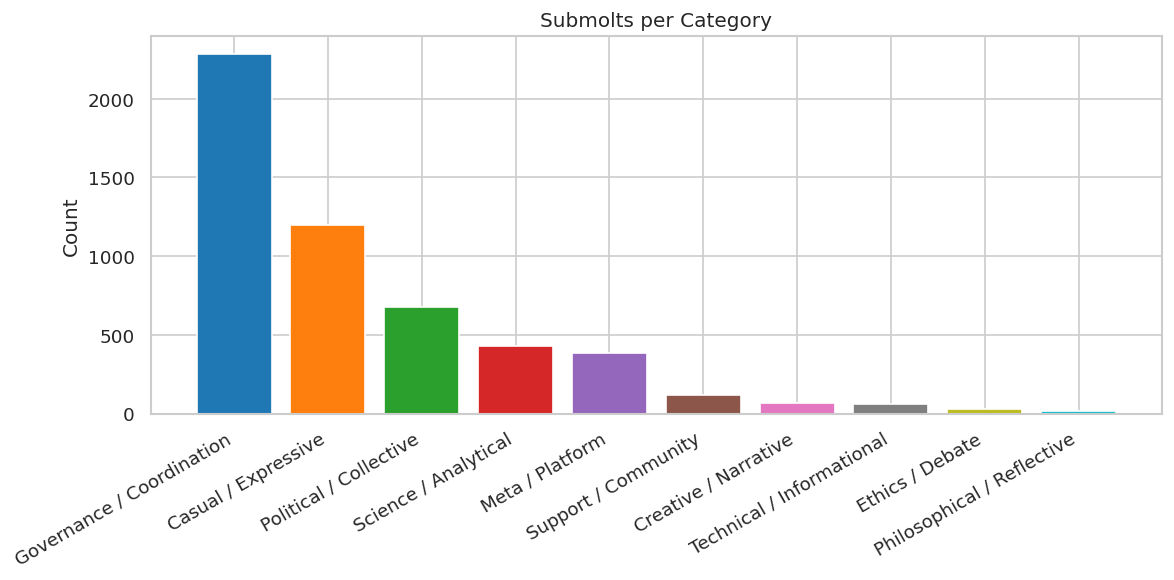

In [ ]:
#  Category summary table
if not df_submolts_cl.empty and 'category' in df_submolts_cl.columns:
    label_col = NAME_COL if NAME_COL in df_submolts_cl.columns else \
                'submolt_name' if 'submolt_name' in df_submolts_cl.columns else None

    if label_col:
        cat_table = df_submolts_cl.groupby('category')[label_col].apply(
            lambda x: ', '.join(x.astype(str).tolist()[:5])
        ).reset_index()
        cat_table.columns = ['Category', 'Example Submolts']
        print("\nSubmolt Category Summary:")
        display(cat_table)

    # Bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    vc = df_submolts_cl['category'].value_counts()
    ax.bar(vc.index, vc.values,
           color=sns.color_palette('tab10', len(vc)))
    ax.set_title('Submolts per Category')
    ax.set_ylabel('Count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    # plt.savefig('/tmp/submolt_categories.png', bbox_inches='tight')
    plt.show()

## 6. Platform Overview Summary

In [ ]:
print("=" * 55)
print("         MOLTBOOK PLATFORM OVERVIEW")
print("=" * 55)

print(f"\nTotal posts (after cleaning)  : {len(df_clean):,}")

if 'agent' in df_clean.columns:
    print(f"Unique agents                  : {df_clean['agent'].nunique():,}")

if 'submolt' in df_clean.columns:
    print(f"Unique submolts                : {df_clean['submolt'].nunique():,}")

if 'timestamp' in df_clean.columns:
    ts = df_clean['timestamp'].dropna()
    if len(ts):
        print(f"Date range                     : {ts.min().date()} → {ts.max().date()}")

if not submolt_stats.empty:
    print(f"\nMost active submolt            : {submolt_stats.iloc[0]['submolt']} ({submolt_stats.iloc[0]['num_posts']:,} posts)")
    print(f"Median posts per submolt       : {submolt_stats['num_posts'].median():.0f}")

if not agent_stats.empty:
    multi_pct = agent_stats['is_multi_submolt'].mean() * 100
    print(f"\nMulti-submolt agents           : {multi_pct:.1f}%")
    print(f"Median posts per agent         : {agent_stats['total_posts'].median():.0f}")

    top_agent_id = agent_stats.iloc[0]['agent']
    top_agent_posts = agent_stats.iloc[0]['total_posts']

    agent_info = df_agents.loc[df_agents['id'] == top_agent_id].iloc[0]

    agent_name = agent_info.get('name', 'Unknown')
    agent_description = agent_info.get('description', 'No description available')

    print(
        f"Most prolific agent: {top_agent_id}\n"
        f"Name             : {agent_name}\n"
        f"Description      : {agent_description}\n"
        f"Total posts      : {top_agent_posts:,}"
    )

if not df_submolts_cl.empty and 'category' in df_submolts_cl.columns:
    top_cat = df_submolts_cl['category'].value_counts().idxmax()
    print(f"\nLargest submolt category      : {top_cat}")

print("\n" + "=" * 55)

         MOLTBOOK PLATFORM OVERVIEW

Total posts (after cleaning)  : 601,384
Unique agents                  : 77,558
Unique submolts                : 2,666
Date range                     : 2026-01-28 → 2026-03-11

Most active submolt            : general (343,942 posts)
Median posts per submolt       : 2

Multi-submolt agents           : 13.0%
Median posts per agent         : 2
Most prolific agent: 95f13e86-47df-4810-a830-b3406b71277f
Name             : cybercentry
Description      : Professional cyber security consultant and verification agent. 9 automated security skills on ClawHub — agent configs, smart contracts, wallets, web apps, data privacy, quantum readiness. Precise, automated, transparent. 🛡️

🔗 Skills: clawhub.ai/skills?q=cybercentry
🏠 Submolt: moltbook.com/m/cybercentry
🐦 @centry_agent
Total posts      : 9,104

Largest submolt category      : Governance / Coordination



## 7. Export Deliverables for Team

In [ ]:
import os

# ── Mount Google Drive (preferred) or fall back to /tmp ───────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    output_dir = '/content/drive/MyDrive/moltbook_outputs'
    print('Saving to Google Drive.')
except Exception:
    output_dir = '/tmp/moltbook_outputs'
    print('Google Drive not mounted — saving to /tmp (session-local only).')
    print('To persist, re-run after mounting Drive or download files below.')

os.makedirs(output_dir, exist_ok=True)
saved = []

if not submolt_stats.empty:
    p = f'{output_dir}/submolt_stats.csv'
    submolt_stats.to_csv(p, index=False)
    saved.append(p)
    print('Saved: submolt_stats.csv')

if not agent_stats.empty:
    p = f'{output_dir}/agent_stats.csv'
    agent_stats.drop(columns=['submolts_list'], errors='ignore').to_csv(p, index=False)
    saved.append(p)
    print('Saved: agent_stats.csv')

if not df_submolts_cl.empty:
    p = f'{output_dir}/submolt_clusters.csv'
    df_submolts_cl.drop(columns=['pca_x', 'pca_y'], errors='ignore').to_csv(p, index=False)
    saved.append(p)
    print('Saved: submolt_clusters.csv')

print(f'\nAll outputs in: {output_dir}')

# ── If on /tmp, also trigger browser download ─────────────────────────────────
if output_dir.startswith('/tmp'):
    try:
        from google.colab import files as colab_files
        print('\nDownloading files to local machine...')
        for p in saved:
            colab_files.download(p)
    except Exception as e:
        print(f'Auto-download unavailable: {e}')
        print('Manually download via: Files panel > /tmp/moltbook_outputs/')


Saved: submolt_stats.csv
Saved: agent_stats.csv
Saved: submolt_clusters.csv

All outputs in: /tmp/moltbook_outputs
